In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Basic imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import logging
from pathlib import Path

# Set up logging
logging.basicConfig(level=logging.INFO)

# Analysis utils imports
from polarbert.analysis_utils import (
    load_config,
    load_pretrained_model,
    create_dataloaders,
    validate_model,
    create_mask,
    FlashTransformerAnalyzable,
    batch_to_device
)

In [3]:
config_path = '/groups/pheno/inar/PolarBERT/configs/2027_07_polarbert_IT.yaml'
# config_path = '/groups/pheno/inar/PolarBERT/configs/2027_08_polarbert_trap_IT.yaml'
batch_size = 256  # Smaller batch size for analysis

# The load_config function automatically sets CPU-friendly defaults
config = load_config(config_path, batch_size=batch_size)

# Let's check the use_dom_positions setting
print(f"use_dom_positions: {config.get('embedding', {}).get('use_dom_positions', 'Not found')}")
print(f"use_final_layer_norm: {config.get('use_final_layer_norm', 'Not found')}")

train_loader, val_loader = create_dataloaders(config)

sample_batch, _ = next(iter(val_loader))
print(f"Sample batch shape: {sample_batch[0]['features'].shape}")
print(f"Sample DOM IDs shape: {sample_batch[0]['dom_id'].shape}")

use_dom_positions: Not found
use_final_layer_norm: Not found


INFO:root:Train loader ready: 390624 batches
INFO:root:Val loader ready: 780 batches
INFO:root:Logical batch size: 256


Sample batch shape: torch.Size([256, 127, 3])
Sample DOM IDs shape: torch.Size([256, 127])


In [4]:
# checkpoint_dir = "/groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/kaggle-130M-v3-untuned_250711-151243"

checkpoint_dir = "/groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-100M-trap_250817-182549"

# both work
pth_path = f"{checkpoint_dir}/final_model.pth"
ckpt_path = f"{checkpoint_dir}/last.ckpt"

checkpoint_path = pth_path 

print("Loading model with automatic final_layer_norm detection...")
pretrained_model = load_pretrained_model(
    config=config,
    checkpoint_path=checkpoint_path,
    device='cuda',
    from_scratch=False
)

# Check if the model actually has final_layer_norm after loading
print(f"Model has final_layer_norm after loading: {hasattr(pretrained_model, 'final_layer_norm')}")
if hasattr(pretrained_model, 'final_layer_norm'):
    print(f"final_layer_norm type: {type(pretrained_model.final_layer_norm)}")
else:
    print("final_layer_norm was removed due to checkpoint incompatibility")

INFO:root:Loading checkpoint from: /groups/pheno/inar/PolarBERT/src/polarbert/checkpoints/results/PolarBERT-xyz-100M-trap_250817-182549/final_model.pth


Loading model with automatic final_layer_norm detection...


INFO:root:Loaded pretrained weights successfully!


Model has final_layer_norm after loading: True
final_layer_norm type: <class 'torch.nn.modules.normalization.LayerNorm'>


In [5]:
print("Validating model...")
pretrained_metrics = validate_model(
    model=pretrained_model,
    val_loader=val_loader,
    num_batches=8,
    device='cuda'
)
print(f"Validation loss: {pretrained_metrics['avg_loss']}")
print(f"Validation accuracy: {pretrained_metrics['accuracy']:.4f}")

Validating model...


INFO:root:Validation metrics: {'avg_loss': 2.074868142604828, 'accuracy': 0.2505384946765955, 'total_masked_tokens': 16249, 'total_correct_predictions': 4071, 'batches_processed': 8}


Validation loss: 2.074868142604828
Validation accuracy: 0.2505


In [6]:
pretrained_model.embedding.dom_embedding.weight.shape

torch.Size([5161, 128])

In [7]:
pretrained_model.embedding

AnalyzableEmbedding(
  (dom_embedding): Embedding(5161, 128, padding_idx=0)
  (features_embedding): Linear(in_features=3, out_features=128, bias=True)
)

In [8]:
import pandas as pd


# Load sensor geometry
geometry_df = pd.read_csv('/groups/pheno/inar/icecube_kaggle/sensor_geometry.csv')

# Create position tensor (5161 DOMs total, index 0 is padding)
positions = torch.zeros(5161, 3)  # +1 for padding DOM at index 0
for i in range(len(geometry_df)):
    positions[i + 1] = torch.tensor([geometry_df.iloc[i]['x'], 
                                   geometry_df.iloc[i]['y'], 
                                   geometry_df.iloc[i]['z']])

In [9]:
positions

tensor([[   0.0000,    0.0000,    0.0000],
        [-256.1400, -521.0800,  496.0300],
        [-256.1400, -521.0800,  479.0100],
        ...,
        [ -10.9700,    6.7200, -486.4000],
        [ -10.9700,    6.7200, -493.4100],
        [ -10.9700,    6.7200, -500.7300]])

In [10]:
X = pretrained_model.embedding.dom_embedding.weight.detach().cpu().numpy()
Y = positions.detach().cpu().numpy()

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

# Remove the padding DOM (index 0) since it's zeros
X_train = X[1:]  # Skip padding DOM
Y_train = Y[1:]  # Skip padding DOM

print(f"Training data - X shape: {X_train.shape}, Y shape: {Y_train.shape}")

# Standardize the features (X) for better linear regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train separate linear models for each coordinate (x, y, z)
models = {}
predictions = {}
metrics = {}

for i, coord in enumerate(['x', 'y', 'z']):
    print(f"\nTraining linear model for {coord} coordinate...")
    
    # Create and train the model
    model = LinearRegression()
    model.fit(X_train_scaled, Y_train[:, i])
    models[coord] = model
    
    # Make predictions
    y_pred = model.predict(X_train_scaled)
    predictions[coord] = y_pred
    
    # Calculate metrics
    mse = mean_squared_error(Y_train[:, i], y_pred)
    r2 = r2_score(Y_train[:, i], y_pred)
    
    metrics[coord] = {'mse': mse, 'r2': r2}
    
    print(f"{coord} coordinate - MSE: {mse:.2f}, R²: {r2:.4f}")

print(f"\nOverall R² scores: x={metrics['x']['r2']:.4f}, y={metrics['y']['r2']:.4f}, z={metrics['z']['r2']:.4f}")

X shape: (5161, 128)
Y shape: (5161, 3)
Training data - X shape: (5160, 128), Y shape: (5160, 3)

Training linear model for x coordinate...
x coordinate - MSE: 56975.02, R²: 0.2992

Training linear model for y coordinate...
y coordinate - MSE: 47896.50, R²: 0.3400

Training linear model for z coordinate...
z coordinate - MSE: 21850.44, R²: 0.7513

Overall R² scores: x=0.2992, y=0.3400, z=0.7513


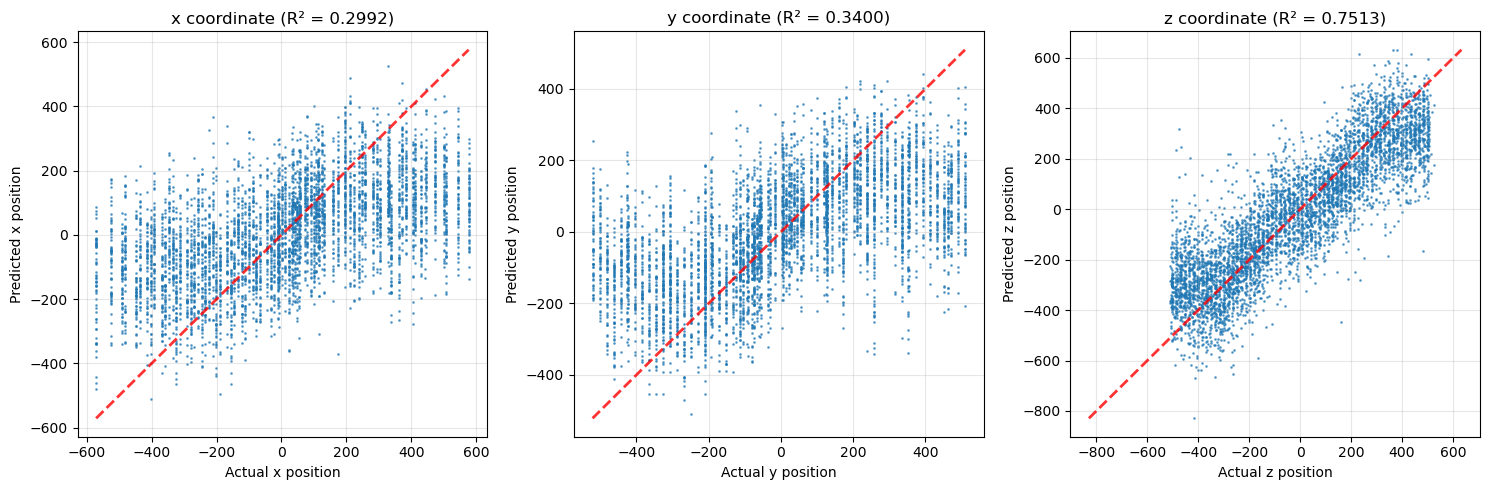


=== Linear Model Summary ===
Number of DOMs: 5160
Embedding dimension: 128
Position coordinates: 3

Prediction Quality:
  x: R² = 0.2992, MSE = 56975.02
  y: R² = 0.3400, MSE = 47896.50
  z: R² = 0.7513, MSE = 21850.44

Mean R² across all coordinates: 0.4635


In [12]:
# Visualize the predictions vs actual positions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, coord in enumerate(['x', 'y', 'z']):
    ax = axes[i]
    
    # Scatter plot of predicted vs actual
    ax.scatter(Y_train[:, i], predictions[coord], alpha=0.6, s=1)
    
    # Perfect prediction line
    min_val = min(Y_train[:, i].min(), predictions[coord].min())
    max_val = max(Y_train[:, i].max(), predictions[coord].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax.set_xlabel(f'Actual {coord} position')
    ax.set_ylabel(f'Predicted {coord} position')
    ax.set_title(f'{coord} coordinate (R² = {metrics[coord]["r2"]:.4f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Linear Model Summary ===")
print(f"Number of DOMs: {len(X_train)}")
print(f"Embedding dimension: {X_train.shape[1]}")
print(f"Position coordinates: {Y_train.shape[1]}")
print("\nPrediction Quality:")
for coord in ['x', 'y', 'z']:
    print(f"  {coord}: R² = {metrics[coord]['r2']:.4f}, MSE = {metrics[coord]['mse']:.2f}")

# Calculate overall correlation
overall_r2 = np.mean([metrics[coord]['r2'] for coord in ['x', 'y', 'z']])
print(f"\nMean R² across all coordinates: {overall_r2:.4f}")

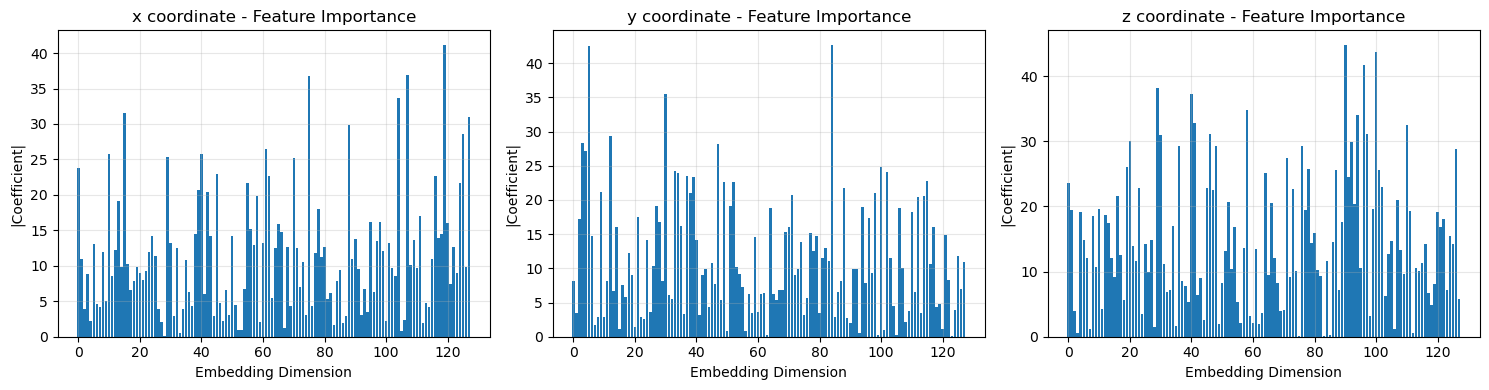


=== Most Important Embedding Dimensions ===

x coordinate - Top 5 most predictive dimensions:
  Dimension 119: coefficient = -41.1450
  Dimension 107: coefficient = -36.8400
  Dimension 75: coefficient = -36.6991
  Dimension 104: coefficient = 33.6795
  Dimension 15: coefficient = -31.5066

y coordinate - Top 5 most predictive dimensions:
  Dimension 84: coefficient = 42.6673
  Dimension 5: coefficient = 42.5480
  Dimension 30: coefficient = -35.5258
  Dimension 12: coefficient = 29.3140
  Dimension 3: coefficient = 28.3221

z coordinate - Top 5 most predictive dimensions:
  Dimension 90: coefficient = -44.7943
  Dimension 100: coefficient = -43.7018
  Dimension 96: coefficient = -41.7771
  Dimension 29: coefficient = 38.2419
  Dimension 40: coefficient = 37.2675

=== Testing Model Compression ===
x: Full model R² = 0.2992, Compressed R² = 0.2509
y: Full model R² = 0.3400, Compressed R² = 0.2960
z: Full model R² = 0.7513, Compressed R² = 0.6699

Using top 50 features retains 87.5% of 

In [13]:
# Analyze feature importance (coefficients)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, coord in enumerate(['x', 'y', 'z']):
    ax = axes[i]
    
    # Get the coefficients (feature importance)
    coeffs = models[coord].coef_
    
    # Plot coefficient magnitudes
    ax.bar(range(len(coeffs)), np.abs(coeffs))
    ax.set_xlabel('Embedding Dimension')
    ax.set_ylabel('|Coefficient|')
    ax.set_title(f'{coord} coordinate - Feature Importance')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the most important features for each coordinate
print("\n=== Most Important Embedding Dimensions ===")
for coord in ['x', 'y', 'z']:
    coeffs = models[coord].coef_
    top_indices = np.argsort(np.abs(coeffs))[-5:][::-1]  # Top 5 most important
    
    print(f"\n{coord} coordinate - Top 5 most predictive dimensions:")
    for idx in top_indices:
        print(f"  Dimension {idx}: coefficient = {coeffs[idx]:.4f}")

# Test if we can compress the model by using only the most important features
print("\n=== Testing Model Compression ===")
top_n_features = 50  # Use only top 50 features

compressed_metrics = {}
for coord in ['x', 'y', 'z']:
    coeffs = models[coord].coef_
    top_indices = np.argsort(np.abs(coeffs))[-top_n_features:]
    
    # Train new model with only top features
    compressed_model = LinearRegression()
    X_compressed = X_train_scaled[:, top_indices]
    compressed_model.fit(X_compressed, Y_train[:, {'x': 0, 'y': 1, 'z': 2}[coord]])
    
    # Evaluate
    y_pred_compressed = compressed_model.predict(X_compressed)
    r2_compressed = r2_score(Y_train[:, {'x': 0, 'y': 1, 'z': 2}[coord]], y_pred_compressed)
    
    compressed_metrics[coord] = r2_compressed
    print(f"{coord}: Full model R² = {metrics[coord]['r2']:.4f}, Compressed R² = {r2_compressed:.4f}")

print(f"\nUsing top {top_n_features} features retains {np.mean(list(compressed_metrics.values()))/overall_r2*100:.1f}% of predictive power")

In [14]:
# Non-linear models for multi-output regression (predicting all xyz simultaneously)
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
import time

print("=== Training Non-Linear Models ===")
print(f"Input shape: {X_train_scaled.shape}")
print(f"Output shape: {Y_train.shape}")

# Split data for proper evaluation
X_train_split, X_test_split, Y_train_split, Y_test_split = train_test_split(
    X_train_scaled, Y_train, test_size=0.2, random_state=42
)

print(f"Train set: {X_train_split.shape} -> {Y_train_split.shape}")
print(f"Test set: {X_test_split.shape} -> {Y_test_split.shape}")

# Dictionary to store models and results
nonlinear_models = {}
nonlinear_results = {}

# 1. Random Forest (handles multi-output naturally)
print("\n1. Training Random Forest...")
start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train_split, Y_train_split)
rf_pred = rf_model.predict(X_test_split)
rf_time = time.time() - start_time

nonlinear_models['Random Forest'] = rf_model
nonlinear_results['Random Forest'] = {
    'predictions': rf_pred,
    'training_time': rf_time
}

print(f"Random Forest trained in {rf_time:.2f}s")

# 2. Neural Network (MLP)
print("\n2. Training Neural Network (MLP)...")
start_time = time.time()
mlp_model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_model.fit(X_train_split, Y_train_split)
mlp_pred = mlp_model.predict(X_test_split)
mlp_time = time.time() - start_time

nonlinear_models['Neural Network'] = mlp_model
nonlinear_results['Neural Network'] = {
    'predictions': mlp_pred,
    'training_time': mlp_time
}

print(f"Neural Network trained in {mlp_time:.2f}s")

# 3. Support Vector Regression (multi-output)
print("\n3. Training Support Vector Regression...")
start_time = time.time()
svr_model = MultiOutputRegressor(
    SVR(kernel='rbf', C=1.0, gamma='scale'),
    n_jobs=-1
)
svr_model.fit(X_train_split, Y_train_split)
svr_pred = svr_model.predict(X_test_split)
svr_time = time.time() - start_time

nonlinear_models['SVR'] = svr_model
nonlinear_results['SVR'] = {
    'predictions': svr_pred,
    'training_time': svr_time
}

print(f"SVR trained in {svr_time:.2f}s")

print("\nAll non-linear models trained successfully!")

=== Training Non-Linear Models ===
Input shape: (5160, 128)
Output shape: (5160, 3)
Train set: (4128, 128) -> (4128, 3)
Test set: (1032, 128) -> (1032, 3)

1. Training Random Forest...
Random Forest trained in 0.84s

2. Training Neural Network (MLP)...
Neural Network trained in 1.18s

3. Training Support Vector Regression...
SVR trained in 10.91s

All non-linear models trained successfully!


In [15]:
# Evaluate non-linear models
print("\n=== Non-Linear Model Evaluation ===")

# Calculate metrics for each model
model_comparison = {}

for model_name, result in nonlinear_results.items():
    predictions = result['predictions']
    
    # Calculate R² for each coordinate
    r2_scores = {}
    mse_scores = {}
    
    for i, coord in enumerate(['x', 'y', 'z']):
        r2 = r2_score(Y_test_split[:, i], predictions[:, i])
        mse = mean_squared_error(Y_test_split[:, i], predictions[:, i])
        r2_scores[coord] = r2
        mse_scores[coord] = mse
    
    # Overall metrics
    mean_r2 = np.mean(list(r2_scores.values()))
    mean_mse = np.mean(list(mse_scores.values()))
    
    model_comparison[model_name] = {
        'r2_scores': r2_scores,
        'mse_scores': mse_scores,
        'mean_r2': mean_r2,
        'mean_mse': mean_mse,
        'training_time': result['training_time']
    }
    
    print(f"\n{model_name}:")
    print(f"  Mean R²: {mean_r2:.4f}")
    print(f"  Individual R²: x={r2_scores['x']:.4f}, y={r2_scores['y']:.4f}, z={r2_scores['z']:.4f}")
    print(f"  Training time: {result['training_time']:.2f}s")

# Compare with linear model (need to evaluate on same test set)
print(f"\n=== Comparison with Linear Model ===")
linear_pred_test = np.column_stack([
    models['x'].predict(X_test_split),
    models['y'].predict(X_test_split), 
    models['z'].predict(X_test_split)
])

linear_r2_test = {}
for i, coord in enumerate(['x', 'y', 'z']):
    linear_r2_test[coord] = r2_score(Y_test_split[:, i], linear_pred_test[:, i])

linear_mean_r2_test = np.mean(list(linear_r2_test.values()))
print(f"Linear Model (test set): Mean R² = {linear_mean_r2_test:.4f}")
print(f"  Individual R²: x={linear_r2_test['x']:.4f}, y={linear_r2_test['y']:.4f}, z={linear_r2_test['z']:.4f}")

# Summary comparison
print(f"\n=== Performance Ranking ===")
all_models = {**model_comparison, 'Linear': {'mean_r2': linear_mean_r2_test}}
sorted_models = sorted(all_models.items(), key=lambda x: x[1]['mean_r2'], reverse=True)

for i, (name, metrics) in enumerate(sorted_models, 1):
    print(f"{i}. {name}: R² = {metrics['mean_r2']:.4f}")
    if name != 'Linear':
        improvement = (metrics['mean_r2'] - linear_mean_r2_test) / linear_mean_r2_test * 100
        print(f"   Improvement over linear: {improvement:+.1f}%")


=== Non-Linear Model Evaluation ===

Random Forest:
  Mean R²: 0.1835
  Individual R²: x=0.1025, y=0.1020, z=0.3461
  Training time: 0.84s

Neural Network:
  Mean R²: 0.6843
  Individual R²: x=0.5574, y=0.6162, z=0.8793
  Training time: 1.18s

SVR:
  Mean R²: 0.0354
  Individual R²: x=0.0171, y=0.0232, z=0.0659
  Training time: 10.91s

=== Comparison with Linear Model ===
Linear Model (test set): Mean R² = 0.4659
  Individual R²: x=0.2878, y=0.3678, z=0.7421

=== Performance Ranking ===
1. Neural Network: R² = 0.6843
   Improvement over linear: +46.9%
2. Linear: R² = 0.4659
3. Random Forest: R² = 0.1835
   Improvement over linear: -60.6%
4. SVR: R² = 0.0354
   Improvement over linear: -92.4%


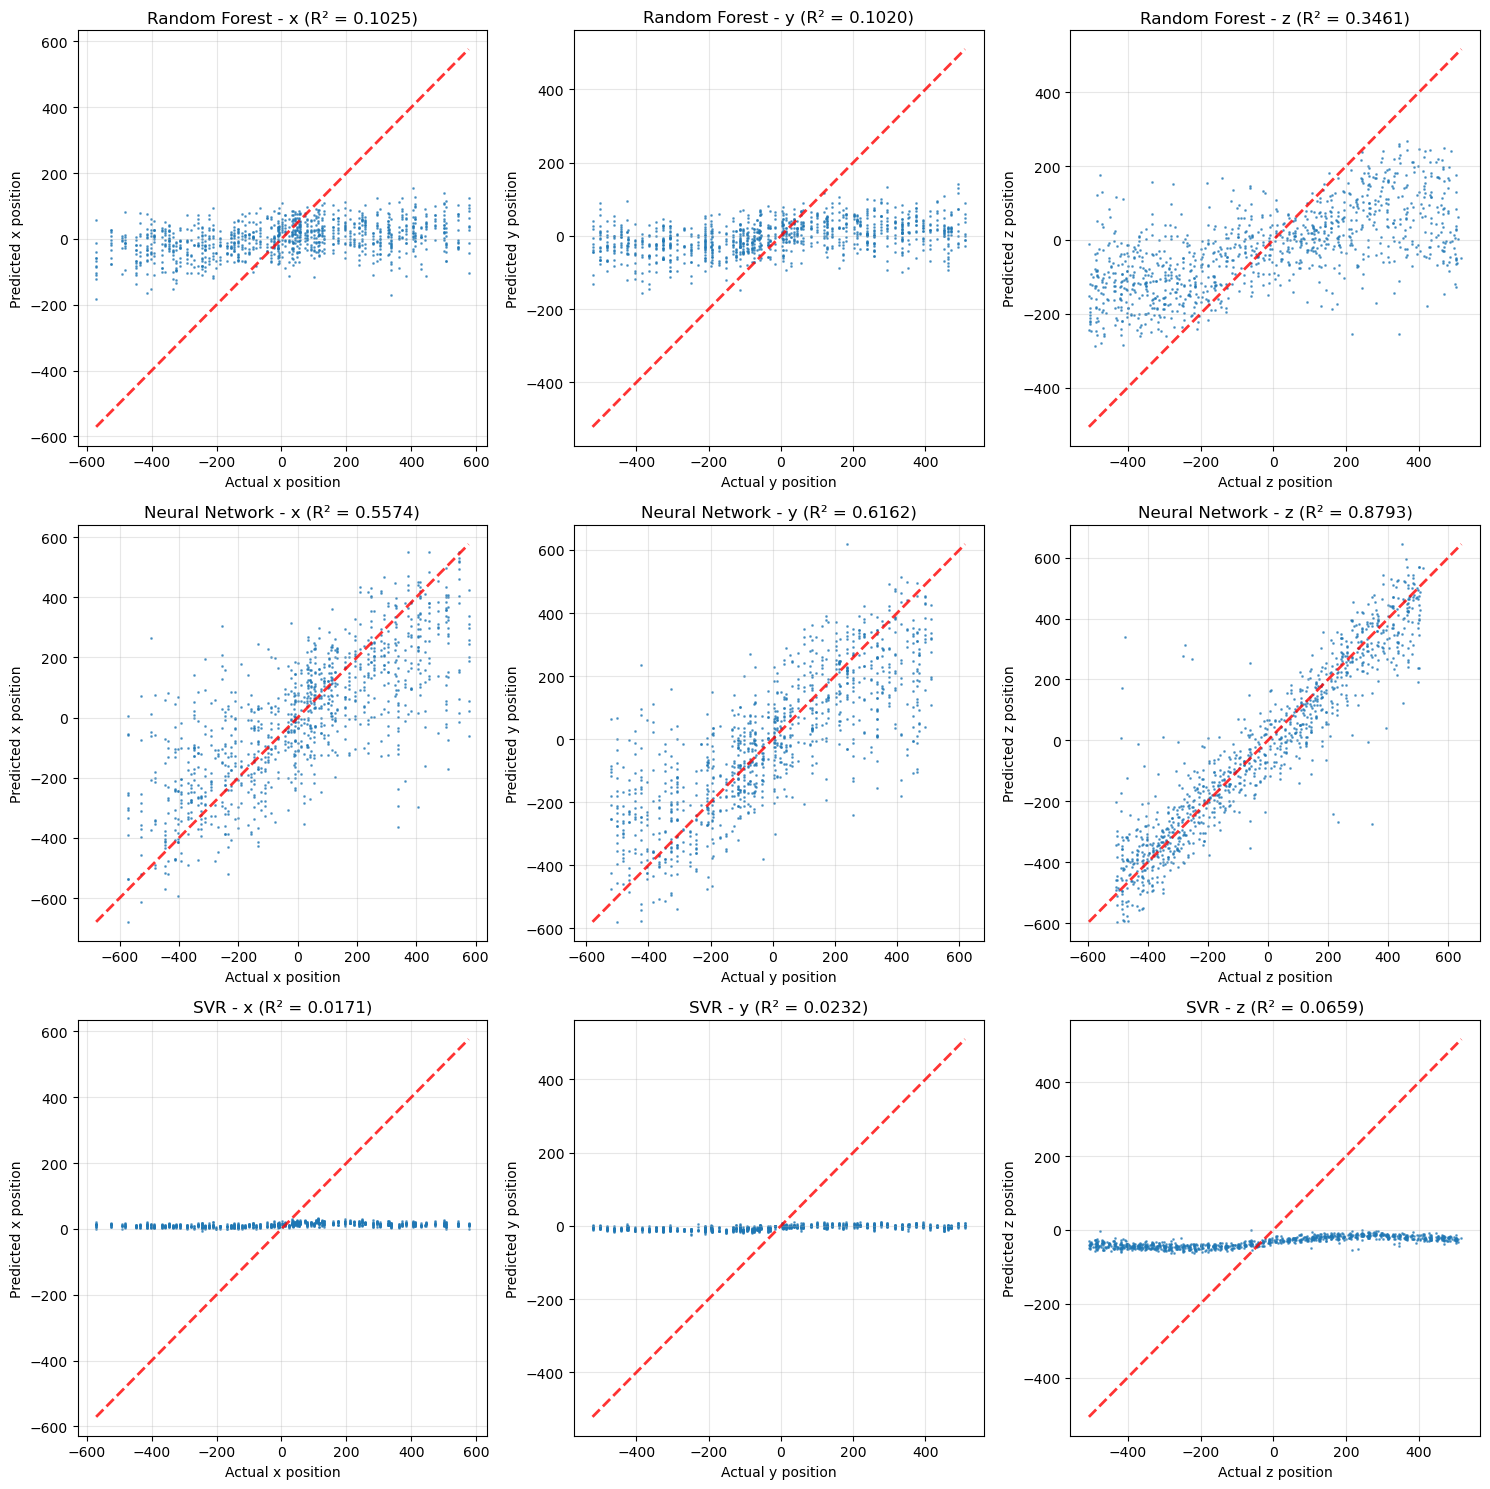

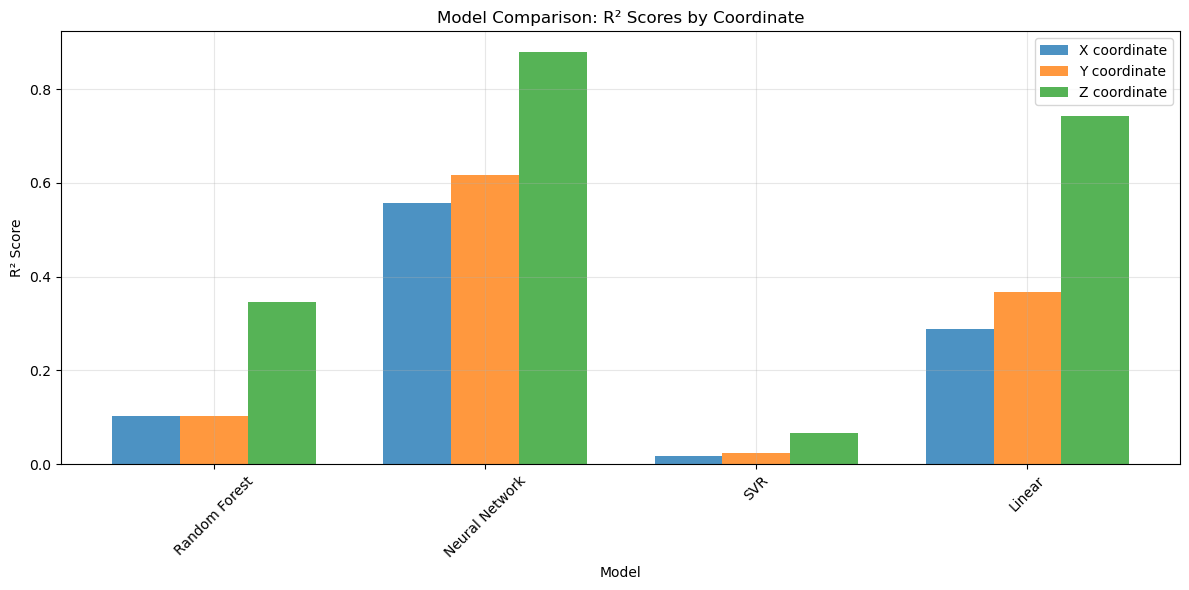


=== Random Forest Feature Importance ===
Top 10 most important embedding dimensions:
 1. Dimension 40: importance = 0.0276
 2. Dimension 96: importance = 0.0214
 3. Dimension 29: importance = 0.0213
 4. Dimension 90: importance = 0.0163
 5. Dimension 30: importance = 0.0145
 6. Dimension 76: importance = 0.0138
 7. Dimension 94: importance = 0.0138
 8. Dimension 48: importance = 0.0127
 9. Dimension 20: importance = 0.0121
10. Dimension 58: importance = 0.0118


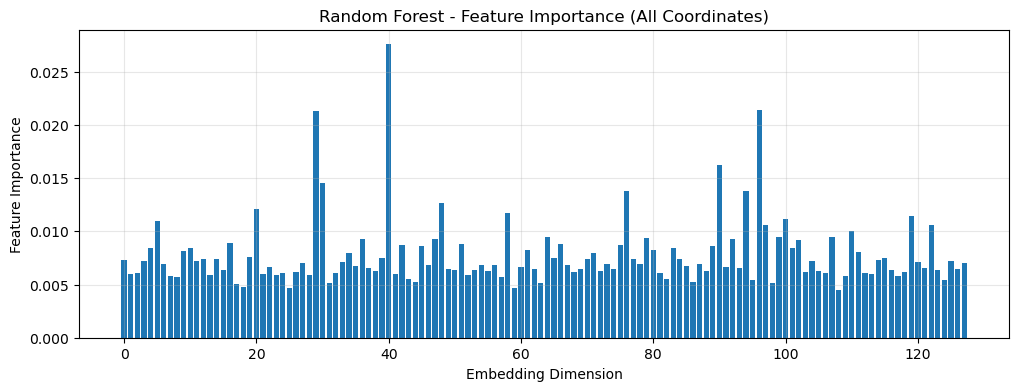

In [16]:
# Visualize non-linear model predictions
fig, axes = plt.subplots(len(nonlinear_results), 3, figsize=(15, 5*len(nonlinear_results)))
if len(nonlinear_results) == 1:
    axes = axes.reshape(1, -1)

for row, (model_name, result) in enumerate(nonlinear_results.items()):
    predictions = result['predictions']
    
    for col, coord in enumerate(['x', 'y', 'z']):
        ax = axes[row, col]
        
        # Scatter plot
        ax.scatter(Y_test_split[:, col], predictions[:, col], alpha=0.6, s=1)
        
        # Perfect prediction line
        min_val = min(Y_test_split[:, col].min(), predictions[:, col].min())
        max_val = max(Y_test_split[:, col].max(), predictions[:, col].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
        
        # Labels and title
        r2 = model_comparison[model_name]['r2_scores'][coord]
        ax.set_xlabel(f'Actual {coord} position')
        ax.set_ylabel(f'Predicted {coord} position')
        ax.set_title(f'{model_name} - {coord} (R² = {r2:.4f})')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bar chart comparing R² scores
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(model_comparison.keys()) + ['Linear']
x_coords = [model_comparison[name]['r2_scores']['x'] for name in model_comparison.keys()] + [linear_r2_test['x']]
y_coords = [model_comparison[name]['r2_scores']['y'] for name in model_comparison.keys()] + [linear_r2_test['y']]
z_coords = [model_comparison[name]['r2_scores']['z'] for name in model_comparison.keys()] + [linear_r2_test['z']]

x = np.arange(len(model_names))
width = 0.25

ax.bar(x - width, x_coords, width, label='X coordinate', alpha=0.8)
ax.bar(x, y_coords, width, label='Y coordinate', alpha=0.8)
ax.bar(x + width, z_coords, width, label='Z coordinate', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison: R² Scores by Coordinate')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance for Random Forest
if 'Random Forest' in nonlinear_models:
    print("\n=== Random Forest Feature Importance ===")
    rf_model = nonlinear_models['Random Forest']
    
    # Get feature importance for each output
    importances = rf_model.feature_importances_
    
    # Plot feature importance
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(importances)), importances)
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Feature Importance')
    plt.title('Random Forest - Feature Importance (All Coordinates)')
    plt.grid(True, alpha=0.3)
    
    # Show top 10 most important features
    top_indices = np.argsort(importances)[-10:][::-1]
    print("Top 10 most important embedding dimensions:")
    for i, idx in enumerate(top_indices, 1):
        print(f"{i:2d}. Dimension {idx}: importance = {importances[idx]:.4f}")
    
    plt.show()

In [17]:
# Additional advanced models
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

print("\n=== Training Additional Advanced Models ===")

# 4. Gradient Boosting
print("\n4. Training Gradient Boosting...")
start_time = time.time()
gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ),
    n_jobs=-1
)
gb_model.fit(X_train_split, Y_train_split)
gb_pred = gb_model.predict(X_test_split)
gb_time = time.time() - start_time

print(f"Gradient Boosting trained in {gb_time:.2f}s")

# Evaluate Gradient Boosting
gb_r2_scores = {}
for i, coord in enumerate(['x', 'y', 'z']):
    gb_r2_scores[coord] = r2_score(Y_test_split[:, i], gb_pred[:, i])

gb_mean_r2 = np.mean(list(gb_r2_scores.values()))
print(f"Gradient Boosting: Mean R² = {gb_mean_r2:.4f}")
print(f"  Individual R²: x={gb_r2_scores['x']:.4f}, y={gb_r2_scores['y']:.4f}, z={gb_r2_scores['z']:.4f}")

# 5. Deeper Neural Network
print("\n5. Training Deeper Neural Network...")
start_time = time.time()
deep_mlp_model = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate='adaptive'
)
deep_mlp_model.fit(X_train_split, Y_train_split)
deep_mlp_pred = deep_mlp_model.predict(X_test_split)
deep_mlp_time = time.time() - start_time

print(f"Deep Neural Network trained in {deep_mlp_time:.2f}s")

# Evaluate Deep Neural Network
deep_mlp_r2_scores = {}
for i, coord in enumerate(['x', 'y', 'z']):
    deep_mlp_r2_scores[coord] = r2_score(Y_test_split[:, i], deep_mlp_pred[:, i])

deep_mlp_mean_r2 = np.mean(list(deep_mlp_r2_scores.values()))
print(f"Deep Neural Network: Mean R² = {deep_mlp_mean_r2:.4f}")
print(f"  Individual R²: x={deep_mlp_r2_scores['x']:.4f}, y={deep_mlp_r2_scores['y']:.4f}, z={deep_mlp_r2_scores['z']:.4f}")

# Final comprehensive comparison
print(f"\n=== Final Model Comparison ===")
final_comparison = {
    'Linear': linear_mean_r2_test,
    'Random Forest': model_comparison['Random Forest']['mean_r2'],
    'Neural Network': model_comparison['Neural Network']['mean_r2'],
    'SVR': model_comparison['SVR']['mean_r2'],
    'Gradient Boosting': gb_mean_r2,
    'Deep Neural Network': deep_mlp_mean_r2
}

print("Ranking by Mean R² Score:")
sorted_final = sorted(final_comparison.items(), key=lambda x: x[1], reverse=True)
for i, (name, score) in enumerate(sorted_final, 1):
    improvement = (score - linear_mean_r2_test) / linear_mean_r2_test * 100 if name != 'Linear' else 0
    print(f"{i}. {name}: R² = {score:.4f} ({improvement:+.1f}% vs Linear)")

# Best model analysis
best_model, best_score = sorted_final[0]
print(f"\n🏆 Best performing model: {best_model} with R² = {best_score:.4f}")
improvement_pct = (best_score - linear_mean_r2_test) / linear_mean_r2_test * 100
print(f"   This is {improvement_pct:.1f}% better than the linear baseline!")


=== Training Additional Advanced Models ===

4. Training Gradient Boosting...
Gradient Boosting trained in 32.34s
Gradient Boosting: Mean R² = 0.3526
  Individual R²: x=0.2340, y=0.2395, z=0.5842

5. Training Deeper Neural Network...
Deep Neural Network trained in 2.73s
Deep Neural Network: Mean R² = 0.6973
  Individual R²: x=0.5815, y=0.6145, z=0.8959

=== Final Model Comparison ===
Ranking by Mean R² Score:
1. Deep Neural Network: R² = 0.6973 (+49.7% vs Linear)
2. Neural Network: R² = 0.6843 (+46.9% vs Linear)
3. Linear: R² = 0.4659 (+0.0% vs Linear)
4. Gradient Boosting: R² = 0.3526 (-24.3% vs Linear)
5. Random Forest: R² = 0.1835 (-60.6% vs Linear)
6. SVR: R² = 0.0354 (-92.4% vs Linear)

🏆 Best performing model: Deep Neural Network with R² = 0.6973
   This is 49.7% better than the linear baseline!
